1. Experiment 1: Industry ESG Benchmarking

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the dataset
df = pd.read_csv('ESGdataset.csv')

In [4]:
# Data Cleaning & Preparation
score_cols = ['environment_score', 'social_score', 'governance_score', 'total_score']
df[score_cols] = df[score_cols].apply(pd.to_numeric, errors='coerce')
df_cleaned = df.dropna(subset=['industry']).copy()

# Identify the top 10 most frequent industries
top_industries = df_cleaned['industry'].value_counts().nlargest(10).index.tolist()

# Calculate mean scores for the top 10 industries
df_industry_avg = df_cleaned[df_cleaned['industry'].isin(top_industries)].groupby('industry')[score_cols].mean().reset_index()

# Sort industries (rows) by mean total score
df_industry_avg = df_industry_avg.sort_values(by='total_score', ascending=False)

# Prepare data for the plot (melting E, S, G scores into a single column)
df_plot = df_industry_avg.drop(columns=['total_score']).melt(id_vars='industry', var_name='Pillar', value_name='Mean Score')

# Visualization
plt.figure(figsize=(14, 8))
sns.barplot(
    data=df_plot,
    y='industry',
    x='Mean Score',
    hue='Pillar',
    palette={'environment_score': '#1f77b4', 'social_score': '#ff7f0e', 'governance_score': '#2ca02c'}
)
plt.title('Mean ESG Scores by Top 10 Industries (Sorted by Total Score)', fontsize=16)
plt.xlabel('Mean ESG Score')
plt.ylabel('Industry')
plt.legend(title='ESG Pillar', loc='lower right')
plt.tight_layout()
plt.savefig('industry_benchmarking.png')
plt.close()

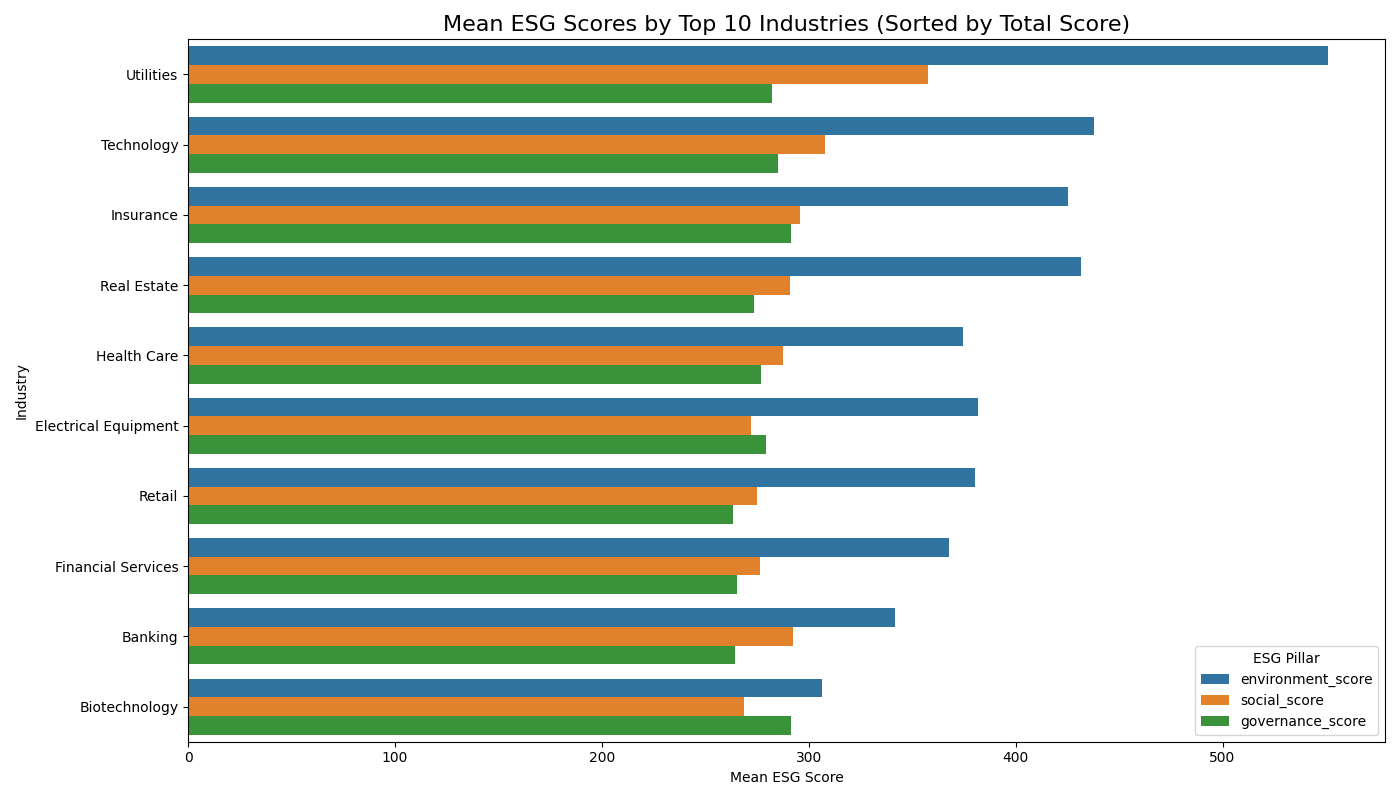

2. Experiment 2: Correlation Analysis (Pillar Relationships)

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data loading and cleaning (from setup)
df = pd.read_csv('ESGdataset.csv')
score_cols = ['environment_score', 'social_score', 'governance_score', 'total_score']
df[score_cols] = df[score_cols].apply(pd.to_numeric, errors='coerce')
df_cleaned = df.dropna(subset=['industry']).copy()

# Calculate the correlation matrix
correlation_matrix = df_cleaned[score_cols[:3]].corr()

# Visualization for Experiment 2
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='viridis',
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title('Correlation Matrix of E, S, and G Scores', fontsize=14)
plt.tight_layout()
plt.savefig('correlation_matrix.png')
plt.close()

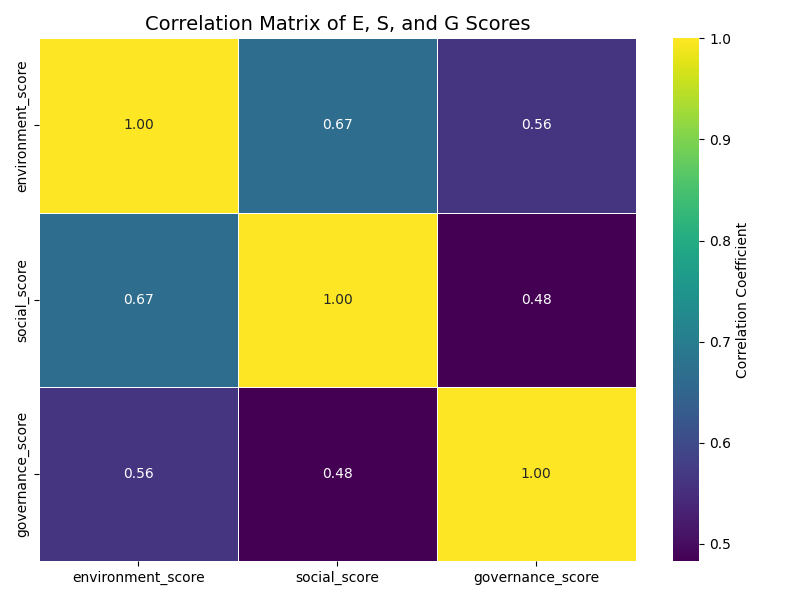

3. Experiment 3: Total Performance Deep Dive

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data loading
df = pd.read_csv('ESGdataset.csv')
score_cols = ['environment_score', 'social_score', 'governance_score', 'total_score']
df[score_cols] = df[score_cols].apply(pd.to_numeric, errors='coerce')

# a) Grade Distribution
grade_order = ['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'CCC', 'CC', 'C']
grade_counts = df['total_grade'].value_counts().reindex(grade_order).dropna()

# Visualization for Grade Distribution
plt.figure(figsize=(10, 6))
sns.barplot(x=grade_counts.index, y=grade_counts.values, palette='RdYlGn')
plt.title('Distribution of Overall ESG Grades', fontsize=16)
plt.xlabel('Total ESG Grade')
plt.ylabel('Number of Companies')
plt.tight_layout()
plt.savefig('grade_distribution.png')
plt.close()

# b) Top and Bottom Performers
top_5 = df.sort_values(by='total_score', ascending=False).head(5)[['name', 'industry', 'total_score', 'total_grade', 'environment_grade', 'social_grade', 'governance_grade']]
bottom_5 = df.sort_values(by='total_score', ascending=True).head(5)[['name', 'industry', 'total_score', 'total_grade', 'environment_grade', 'social_grade', 'governance_grade']]



/tmp/ipython-input-1396475241.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=grade_counts.index, y=grade_counts.values, palette='RdYlGn')


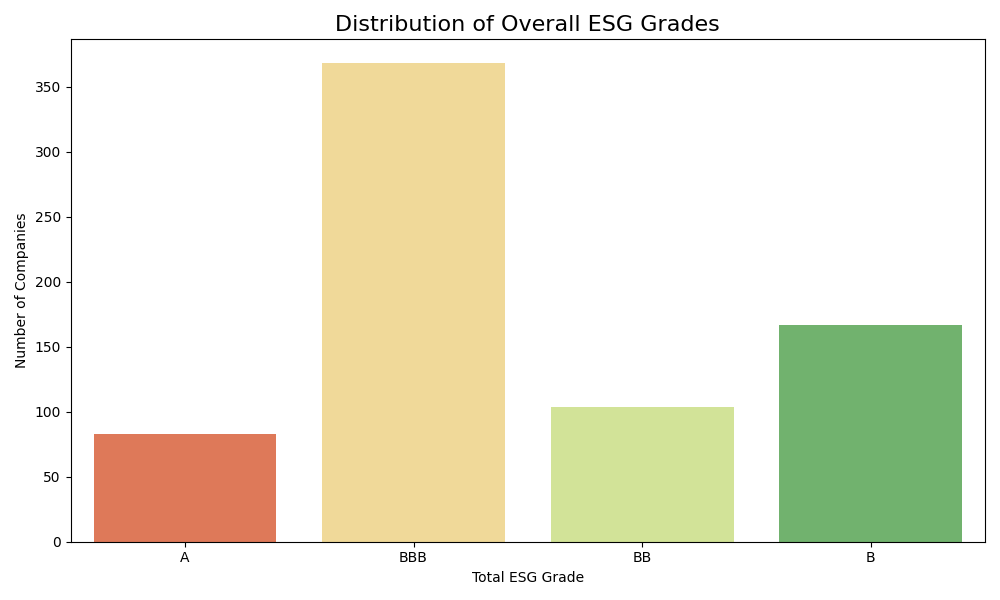